In [4]:
!pip install -q "transformers>=5.0" "accelerate>=1.0" "evaluate>=0.4"


In [1]:
# =============================================================================
# 0. Imports y configuración
# =============================================================================
import json
import time
from pathlib import Path
 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
 
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
 
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
 
SEED = 42
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


In [5]:
# =============================================================================
# 1. Constantes del taller
# =============================================================================
# Reutilizamos nb1_config.json solo para NUM_CLASSES y LABEL_NAMES.
# El tokenizer y MAX_LEN son propios de BERT.
 
with open("nb1_config.json") as f:
    config = json.load(f)
 
NUM_CLASSES = config["num_classes"]
LABEL_NAMES = {int(k): v for k, v in config["label_names"].items()}
 
# ← cambia aquí para probar otros modelos:
#   "bert-base-uncased"         ~110M params
#   "distilbert-base-uncased"   ~66M  params (recomendado si hay limitaciones de GPU)
#   "roberta-base"              ~125M params
#   "albert-base-v2"            ~12M  params
MODEL_NAME  = "distilbert-base-uncased"
MAX_LEN     = 128                   # longitud estándar para tweets
BATCH_SIZE  = 32
EPOCHS_FROZEN   = 3                 # fase 1: solo head
EPOCHS_FINETUNE = 5                 # fase 2: encoder completo
LR_HEAD     = 1e-3                  # lr alta para el clasificador nuevo
LR_ENCODER  = 2e-5                  # lr pequeña para no destruir los pesos preentrenados
 
print(f"Clases: {LABEL_NAMES}")


Clases: {0: 'negative', 1: 'neutral', 2: 'positive'}


In [6]:
# =============================================================================
# 2. Tokenizer
# =============================================================================
# AutoTokenizer carga el tokenizer correcto para cualquier modelo.
# DistilBERT y RoBERTa no generan token_type_ids — el Dataset los omite
# automáticamente si el tokenizer no los devuelve.
 
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
PAD_IDX   = tokenizer.pad_token_id
print(f"Modelo         : {MODEL_NAME}")
print(f"Vocab size     : {tokenizer.vocab_size:,}")
print(f"PAD token id   : {PAD_IDX}")



Modelo         : distilbert-base-uncased
Vocab size     : 30,522
PAD token id   : 0


In [7]:
# =============================================================================
# 3. Dataset y DataLoader
# =============================================================================
# El tokenizer devuelve token_type_ids solo si el modelo los usa (BERT, ALBERT).
# DistilBERT y RoBERTa no los generan — el Dataset los incluye solo si existen.
 
import re
 
def clean_tweet(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "[URL]", text)
    text = re.sub(r"@\w+", "[USER]", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text
 
 
class PretrainedTweetDataset(Dataset):
    """
    Dataset compatible con cualquier tokenizer de HuggingFace.
    Incluye token_type_ids en el batch solo si el tokenizer los devuelve.
    """
    def __init__(self, hf_split, tokenizer, max_len: int = MAX_LEN):
        self.data      = hf_split
        self.tokenizer = tokenizer
        self.max_len   = max_len
 
    def __len__(self):
        return len(self.data)
 
    def __getitem__(self, idx):
        example  = self.data[idx]
        encoding = self.tokenizer(
            clean_tweet(example["text"]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        item = {
            "input_ids"      : encoding["input_ids"].squeeze(0),
            "attention_mask" : encoding["attention_mask"].squeeze(0),
            "label"          : torch.tensor(example["label"], dtype=torch.long),
        }
        # token_type_ids solo para modelos que los usan (BERT, ALBERT)
        if "token_type_ids" in encoding:
            item["token_type_ids"] = encoding["token_type_ids"].squeeze(0)
        return item
 
 
def collate_fn(batch):
    out = {
        "input_ids"      : torch.stack([b["input_ids"]      for b in batch]),
        "attention_mask" : torch.stack([b["attention_mask"] for b in batch]),
        "label"          : torch.stack([b["label"]          for b in batch]),
    }
    if "token_type_ids" in batch[0]:
        out["token_type_ids"] = torch.stack([b["token_type_ids"] for b in batch])
    return out
 
 
dataset      = load_dataset("tweet_eval", "sentiment")
train_loader = DataLoader(PretrainedTweetDataset(dataset["train"],      tokenizer),
                          batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(PretrainedTweetDataset(dataset["validation"], tokenizer),
                          batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(PretrainedTweetDataset(dataset["test"],       tokenizer),
                          batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
 
print(f"Batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")
 
# Sanity check de shapes
batch = next(iter(train_loader))
print(f"input_ids      : {batch['input_ids'].shape}")       # (B, 128)
print(f"attention_mask : {batch['attention_mask'].shape}")  # (B, 128)
print(f"labels         : {batch['label'].shape}")           # (B,)


Batches — train: 1426 | val: 63 | test: 384
input_ids      : torch.Size([32, 128])
attention_mask : torch.Size([32, 128])
labels         : torch.Size([32])


In [8]:
# =============================================================================
# 4. Modelo: PretrainedClassifier
# =============================================================================
# Arquitectura:
#
#   input_ids, attention_mask, [token_type_ids]
#       └─ AutoModel → pooler_output si existe (BERT, ALBERT)
#                    → last_hidden_state[:, 0, :] si no  (DistilBERT, RoBERTa)
#            └─ Dropout → Linear(hidden_size, NUM_CLASSES) → logits (B, C)
 
class PretrainedClassifier(nn.Module):
    """
    Clasificador genérico sobre cualquier encoder de HuggingFace.
    Soporta BERT, DistilBERT, RoBERTa, ALBERT, etc. sin cambiar nada más.
 
    Parámetros
    ----------
    model_name      : checkpoint en HuggingFace Hub
    num_classes     : número de clases de salida
    dropout         : tasa de dropout antes de la capa lineal
    freeze_encoder  : si True, congela todos los pesos del encoder
    """
    def __init__(self, model_name: str, num_classes: int,
                 dropout: float = 0.1, freeze_encoder: bool = False):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
 
        # ¿El modelo usa token_type_ids?
        cfg = self.encoder.config
        self.use_token_type_ids = getattr(cfg, "type_vocab_size", 0) > 1
 
        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False
 
        hidden_size     = cfg.hidden_size
        self.drop       = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_classes)
 
    def forward(self, input_ids, attention_mask, token_type_ids=None):
        kwargs = dict(input_ids=input_ids, attention_mask=attention_mask)
        if self.use_token_type_ids and token_type_ids is not None:
            kwargs["token_type_ids"] = token_type_ids
 
        out = self.encoder(**kwargs)
 
        # pooler_output si existe (BERT, ALBERT), si no → token [CLS]
        if hasattr(out, "pooler_output") and out.pooler_output is not None:
            cls_repr = out.pooler_output               # (B, hidden_size)
        else:
            cls_repr = out.last_hidden_state[:, 0, :]  # (B, hidden_size)
 
        return self.classifier(self.drop(cls_repr))    # (B, C)
 
    def unfreeze_encoder(self):
        """Descongela todos los parámetros del encoder."""
        for p in self.encoder.parameters():
            p.requires_grad = True



In [9]:
# =============================================================================
# 5. Utilidades de entrenamiento  (compatible con el pipeline del taller)
# =============================================================================
# NOTA: run_epoch recibe un batch dict en lugar de (ids, labels, lengths).
# La firma del modelo es (input_ids, attention_mask, token_type_ids).
 
criterion = nn.CrossEntropyLoss()
 
 
def _forward(model, batch):
    """Extrae tensores del batch y hace forward, pasando token_type_ids solo si existen."""
    ids    = batch["input_ids"].to(DEVICE)
    mask   = batch["attention_mask"].to(DEVICE)
    labels = batch["label"].to(DEVICE)
    ttype  = batch.get("token_type_ids")
    ttype  = ttype.to(DEVICE) if ttype is not None else None
    return model(ids, mask, ttype), labels
 
 
def run_epoch(model, loader, criterion, optimizer=None):
    """Train si optimizer is not None, eval en otro caso."""
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, correct, n = 0.0, 0, 0
 
    with torch.set_grad_enabled(training):
        for batch in loader:
            logits, labels = _forward(model, batch)
            loss = criterion(logits, labels)
 
            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
 
            total_loss += loss.item() * labels.size(0)
            correct    += (logits.argmax(dim=1) == labels).sum().item()
            n          += labels.size(0)
 
    return total_loss / n, correct / n
 
 
@torch.no_grad()
def evaluate_clf(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    all_preds, all_labels  = [], []
 
    for batch in loader:
        logits, labels = _forward(model, batch)
        loss  = criterion(logits, labels)
        preds = logits.argmax(dim=1)
 
        total_loss += loss.item() * labels.size(0)
        correct    += (preds == labels).sum().item()
        n          += labels.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
 
    return total_loss / n, correct / n, all_preds, all_labels
 
 
class ModelCheckpoint:
    def __init__(self, filepath, monitor="val_acc", mode="max", verbose=True):
        self.filepath = filepath
        self.monitor  = monitor
        self.verbose  = verbose
        self.best     = float("-inf") if mode == "max" else float("inf")
        self.mode     = mode
 
    def step(self, metrics, model):
        value    = metrics[self.monitor]
        improved = value > self.best if self.mode == "max" else value < self.best
        if improved:
            self.best = value
            torch.save(model.state_dict(), self.filepath)
            if self.verbose:
                print(f"  ✓ Mejor modelo guardado ({self.monitor}: {value:.4f})")
        return improved
 
 
def plot_history(histories: dict):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for name, h in histories.items():
        axes[0].plot(h["train_loss"], label=f"{name} train")
        axes[0].plot(h["val_loss"],   label=f"{name} val", linestyle="--")
        axes[1].plot(h["train_acc"],  label=f"{name} train")
        axes[1].plot(h["val_acc"],    label=f"{name} val", linestyle="--")
    axes[0].set_title("Loss");     axes[0].legend(); axes[0].set_xlabel("Época")
    axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].set_xlabel("Época")
    plt.tight_layout()
    plt.show()
 
 
def full_report(model, loader, model_name: str):
    target_names = [LABEL_NAMES[i] for i in range(NUM_CLASSES)]
    _, acc, preds, labels = evaluate_clf(model, loader, criterion)
    print(f"\n{'='*55}")
    print(f"  {model_name} — Test Accuracy: {acc:.4f}")
    print(f"{'='*55}")
    print(classification_report(labels, preds, target_names=target_names, digits=4))
 
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, data, fmt, title in zip(
        axes, [cm, cm_norm], ["d", ".2f"],
        ["Conteos absolutos", "Proporción por clase (recall)"],
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=target_names, yticklabels=target_names, ax=ax)
        ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
        ax.set_title(f"{model_name}\n{title}")
    plt.tight_layout()
    plt.show()


In [10]:
# =============================================================================
# 6. Estrategia de entrenamiento en dos fases
# =============================================================================
# Fase 1 — BERT congelado: solo el clasificador tiene gradientes.
#   • Convergencia rápida. Útil como sanity check y punto de partida.
#   • lr alta (1e-3) porque el clasificador parte de cero.
#
# Fase 2 — BERT descongelado (full fine-tuning):
#   • Todos los parámetros se actualizan.
#   • lr muy pequeña (2e-5) para no destruir los pesos preentrenados.
#   • Se continúa desde los pesos de la Fase 1.
 
# =============================================================================
# 7. Fase 1: BERT congelado
# =============================================================================
 
model = PretrainedClassifier(
    model_name=MODEL_NAME, num_classes=NUM_CLASSES,
    dropout=0.1, freeze_encoder=True,
).to(DEVICE)
 
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"\n[Fase 1 — encoder frozen]")
print(f"Modelo                 : {MODEL_NAME}")
print(f"Parámetros entrenables : {trainable:,}  /  total: {total:,}")
 
opt_frozen = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=LR_HEAD
)
ckpt       = ModelCheckpoint("pretrained_best.pt", monitor="val_acc")
writer1    = SummaryWriter(log_dir="runs/bert_frozen")
 
history_frozen = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
 
for epoch in range(1, EPOCHS_FROZEN + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, opt_frozen)
    val_loss,   val_acc   = run_epoch(model, val_loader,   criterion)
 
    history_frozen["train_loss"].append(train_loss)
    history_frozen["val_loss"].append(val_loss)
    history_frozen["train_acc"].append(train_acc)
    history_frozen["val_acc"].append(val_acc)
 
    writer1.add_scalars("Loss",     {"train": train_loss, "val": val_loss}, epoch)
    writer1.add_scalars("Accuracy", {"train": train_acc,  "val": val_acc},  epoch)
 
    print(f"Epoch {epoch:02d}/{EPOCHS_FROZEN} — "
          f"train loss: {train_loss:.4f}, acc: {train_acc:.3f} | "
          f"val loss: {val_loss:.4f}, acc: {val_acc:.3f}")
    ckpt.step({"val_acc": val_acc}, model)
 
writer1.close()



model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



[Fase 1 — encoder frozen]
Modelo                 : distilbert-base-uncased
Parámetros entrenables : 2,307  /  total: 66,365,187
Epoch 01/3 — train loss: 0.8228, acc: 0.608 | val loss: 0.7741, acc: 0.637
  ✓ Mejor modelo guardado (val_acc: 0.6375)
Epoch 02/3 — train loss: 0.7810, acc: 0.631 | val loss: 0.7613, acc: 0.641
  ✓ Mejor modelo guardado (val_acc: 0.6415)
Epoch 03/3 — train loss: 0.7761, acc: 0.636 | val loss: 0.7582, acc: 0.656
  ✓ Mejor modelo guardado (val_acc: 0.6560)


In [11]:
# =============================================================================
# 8. Fase 2: Full fine-tuning
# =============================================================================
# Continuamos desde los pesos guardados en la Fase 1.
# Descongelamos BERT y usamos lr mucho más pequeña.
 
print(f"\n[Fase 2 — Full fine-tuning]")
model.load_state_dict(torch.load("pretrained_best.pt", map_location=DEVICE))
model.unfreeze_encoder()
 
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros entrenables : {trainable:,}  /  total: {total:,}")
 
opt_finetune = torch.optim.AdamW([
    {"params": model.encoder.parameters(),    "lr": LR_ENCODER},
    {"params": model.classifier.parameters(), "lr": LR_ENCODER * 5},
], weight_decay=0.01)
 
# Scheduler lineal con warmup (convención en fine-tuning de BERT)
total_steps = len(train_loader) * EPOCHS_FINETUNE
warmup_steps = total_steps // 10
 
scheduler = torch.optim.lr_scheduler.LinearLR(
    opt_finetune,
    start_factor=0.1,
    end_factor=1.0,
    total_iters=warmup_steps,
)
 
writer2 = SummaryWriter(log_dir="runs/bert_finetune")
history_finetune = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
global_step = 0
 
for epoch in range(1, EPOCHS_FINETUNE + 1):
    # Training manual para poder step el scheduler por batch durante warmup
    model.train()
    total_loss, correct, n = 0.0, 0, 0
 
    for batch in train_loader:
        logits, labels = _forward(model, batch)
        loss = criterion(logits, labels)
        opt_finetune.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt_finetune.step()
 
        if global_step < warmup_steps:
            scheduler.step()
        global_step += 1
 
        total_loss += loss.item() * labels.size(0)
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        n          += labels.size(0)
 
    train_loss, train_acc = total_loss / n, correct / n
    val_loss,   val_acc   = run_epoch(model, val_loader, criterion)
 
    history_finetune["train_loss"].append(train_loss)
    history_finetune["val_loss"].append(val_loss)
    history_finetune["train_acc"].append(train_acc)
    history_finetune["val_acc"].append(val_acc)
 
    writer2.add_scalars("Loss",     {"train": train_loss, "val": val_loss}, epoch)
    writer2.add_scalars("Accuracy", {"train": train_acc,  "val": val_acc},  epoch)
 
    print(f"Epoch {epoch:02d}/{EPOCHS_FINETUNE} — "
          f"train loss: {train_loss:.4f}, acc: {train_acc:.3f} | "
          f"val loss: {val_loss:.4f}, acc: {val_acc:.3f}")
    ckpt.step({"val_acc": val_acc}, model)
 
writer2.close()



[Fase 2 — Full fine-tuning]
Parámetros entrenables : 66,365,187  /  total: 66,365,187
Epoch 01/5 — train loss: 0.6771, acc: 0.692 | val loss: 0.6179, acc: 0.731
  ✓ Mejor modelo guardado (val_acc: 0.7310)
Epoch 02/5 — train loss: 0.5393, acc: 0.764 | val loss: 0.6116, acc: 0.755
  ✓ Mejor modelo guardado (val_acc: 0.7550)
Epoch 03/5 — train loss: 0.3975, acc: 0.835 | val loss: 0.7064, acc: 0.734
Epoch 04/5 — train loss: 0.2551, acc: 0.898 | val loss: 0.8546, acc: 0.729
Epoch 05/5 — train loss: 0.1670, acc: 0.936 | val loss: 1.2519, acc: 0.723


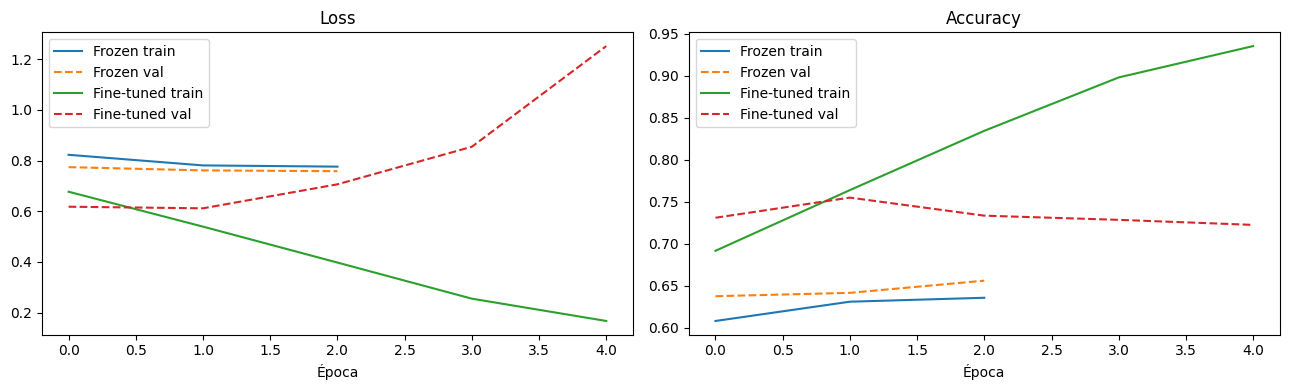


  Fine-tuned (distilbert-base-uncased) — Test Accuracy: 0.6902
              precision    recall  f1-score   support

    negative     0.6921    0.7137    0.7028      3972
     neutral     0.7066    0.6780    0.6920      5937
    positive     0.6493    0.6813    0.6649      2375

    accuracy                         0.6902     12284
   macro avg     0.6827    0.6910    0.6866     12284
weighted avg     0.6909    0.6902    0.6902     12284



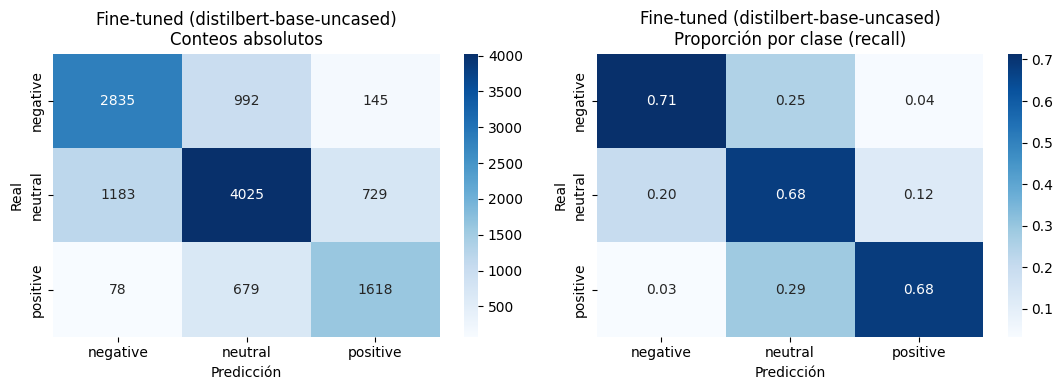

In [12]:
# =============================================================================
# 9. Evaluación comparativa en test
# =============================================================================
 
plot_history({
    "Frozen"     : history_frozen,
    "Fine-tuned" : history_finetune,
})
 
model.load_state_dict(torch.load("pretrained_best.pt", map_location=DEVICE))
full_report(model, test_loader, f"Fine-tuned ({MODEL_NAME})")
